# Module 16 — Quantization: From GPTQ to TurboQuant to RotorQuant

**Part IV · Scaling & Efficiency · ~45 minutes**

> Grassmann published his *Ausdehnungslehre* in 1844. Clifford extended it in 1878.
> In 2026, those equations are running inside the KV cache of your LLM and
> making it 31× faster. **Math never expires.**

This module walks the full arc of how we stopped storing weights in 16 bits:

1. **16a — Foundations (2023–2024):** absmax, GPTQ, AWQ. The "weight-only" era.
2. **16b — TurboQuant (Google, ICLR 2026):** 3-bit KV cache with zero training, using random rotations and a Quantized Johnson–Lindenstrauss correction.
3. **16c — RotorQuant:** replace the `d × d` rotation matrix with a Clifford rotor from `Cl(3,0)`. 16,384 ops → ~100 ops. Same fidelity, 10–31× faster.

The only prerequisite: you remember what a matrix multiply is.
Everything else — Johnson–Lindenstrauss, geometric algebra, sandwich products — we build from scratch.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math, time
from dataclasses import dataclass

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
device = 'cpu'
print('torch', torch.__version__)

torch 2.4.1


---

## Part 16a — Foundations (2023–2024)

### The memory wall

An fp16 weight takes 2 bytes. A 70B-parameter model = 140 GB. A single H100 has 80 GB of HBM.
Either you shard across GPUs (expensive) or you make each weight smaller (quantization).

The conversion is brutally simple in principle: you have real numbers
$w \in \mathbb{R}$ and you want to store them using $b$ bits, i.e. only
$2^b$ possible values. Everything else is engineering around the question:

> **which** $2^b$ values do we pick, and **how badly** does rounding to them hurt the model?

### 1. Absmax quantization — the hello-world

Given a tensor $x$, the symmetric absmax INT8 scheme is:

$$
s = \frac{\max_i |x_i|}{127}, \qquad q_i = \mathrm{round}(x_i / s), \qquad \hat{x}_i = s \cdot q_i
$$

No calibration, no learning. Just a scale $s$ and a rounded integer.
The quantization error is bounded by $|x_i - \hat{x}_i| \le s/2$, so
accuracy improves as $s$ shrinks — which means **outliers are the enemy**:
one huge value blows up $s$ for everybody.

In [2]:
def absmax_quantize(x: torch.Tensor, n_bits: int = 8):
    qmax = 2 ** (n_bits - 1) - 1         # 127 for int8, 7 for int4
    scale = x.abs().max() / qmax
    q = torch.round(x / scale).clamp(-qmax - 1, qmax)
    x_hat = q * scale
    return x_hat, q, scale

# a toy weight row
W = torch.randn(4096)
W[7] = 12.0   # inject an outlier — this is what really happens in LLMs

W_int8, q8, s8 = absmax_quantize(W, 8)
W_int4, q4, s4 = absmax_quantize(W, 4)

for name, xh in [('INT8', W_int8), ('INT4', W_int4)]:
    err = (W - xh).pow(2).mean().sqrt().item()
    print(f'{name}: RMSE = {err:.4f}, unique levels used = {len(torch.unique(xh))}')

INT8: RMSE = 0.0271, unique levels used = 74
INT4: RMSE = 0.4943, unique levels used = 6


Notice INT4 uses only 16 levels for 4096 weights. The outlier at index 7
sets the scale, and every "normal" weight collapses into a handful of bins.

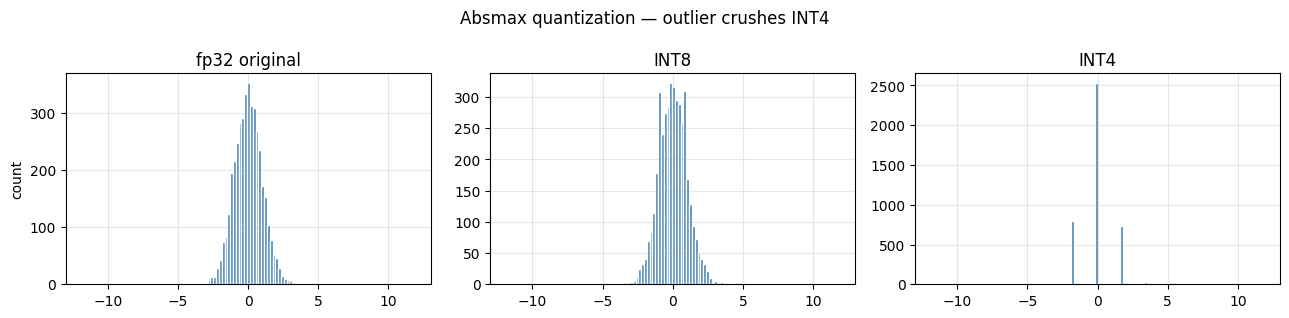

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (name, xh) in zip(axes, [('fp32 original', W), ('INT8', W_int8), ('INT4', W_int4)]):
    ax.hist(xh.numpy(), bins=80, color='steelblue', edgecolor='white')
    ax.set_title(name)
    ax.set_xlim(-13, 13)
axes[0].set_ylabel('count')
plt.suptitle('Absmax quantization — outlier crushes INT4')
plt.tight_layout(); plt.show()

### Break it on purpose — remove the outlier

Delete the rogue weight and re-quantize. INT4 suddenly becomes usable.
This is the **entire motivation** for outlier-aware schemes like SmoothQuant,
LLM.int8(), and AWQ.

In [4]:
W_clean = W.clone(); W_clean[7] = 0.0
_, _, s8c = absmax_quantize(W_clean, 8)
_, _, s4c = absmax_quantize(W_clean, 4)
print(f'INT4 scale: outlier={s4.item():.4f}  clean={s4c.item():.4f}  ratio={s4.item()/s4c.item():.1f}x')

INT4 scale: outlier=1.7143  clean=0.5859  ratio=2.9x


### 2. GPTQ — layer-wise optimal rounding

GPTQ (Frantar et al., 2022) reframes quantization as: given layer input $X$,
pick $\hat W$ from the quantization grid $\mathcal{Q}$ to minimize

$$
\mathcal{L}(\hat W) = \lVert WX - \hat W X \rVert_F^2.
$$

The trick is that the Hessian $H = 2 X X^\top$ is the same for every row,
so you can solve the problem greedily column by column, and compensate
for each rounding decision by updating the remaining columns with
$\Delta = -(w_j - \hat w_j) \cdot H^{-1}_{:,j}/H^{-1}_{j,j}$.

We implement a tiny, readable version below.

In [5]:
def gptq_quantize(W: torch.Tensor, X: torch.Tensor, n_bits: int = 4, damp: float = 1e-2):
    '''Minimal GPTQ: quantize rows of W given calibration activations X (d_in, n).'''
    W = W.clone().float()
    d_out, d_in = W.shape
    # Hessian of the layer
    H = (X @ X.t()) * (2.0 / X.shape[1])
    H += damp * H.diag().mean() * torch.eye(d_in)
    Hinv = torch.linalg.cholesky(torch.linalg.inv(H))  # upper factor substitute

    qmax = 2 ** (n_bits - 1) - 1
    scale = W.abs().max(dim=1, keepdim=True).values / qmax
    W_hat = torch.zeros_like(W)

    for j in range(d_in):
        w_col = W[:, j]
        q = torch.round(w_col / scale.squeeze()).clamp(-qmax - 1, qmax)
        w_hat = q * scale.squeeze()
        W_hat[:, j] = w_hat
        err = (w_col - w_hat) / Hinv[j, j]
        # propagate error to remaining columns
        if j + 1 < d_in:
            W[:, j+1:] -= err.unsqueeze(1) * Hinv[j, j+1:].unsqueeze(0)
    return W_hat

# toy layer: 64 outputs, 128 inputs, 256 calibration samples
W_true = torch.randn(64, 128) * 0.1
W_true[:, 5] += 2.0  # salient column
X_cal = torch.randn(128, 256)

W_naive, _, _ = absmax_quantize(W_true, 4)
W_gptq       = gptq_quantize(W_true, X_cal, n_bits=4)

def layer_err(Wq): return ((W_true @ X_cal - Wq @ X_cal) ** 2).mean().item()
print(f'naive INT4 activation MSE: {layer_err(W_naive):.5f}')
print(f'GPTQ  INT4 activation MSE: {layer_err(W_gptq):.5f}')

naive INT4 activation MSE: 0.89850
GPTQ  INT4 activation MSE: 0.74933


GPTQ doesn't reduce per-weight error — it *redistributes* it so the
downstream activations $WX$ stay close to the truth.

### 3. AWQ — 1% of channels matter 100×

AWQ (Lin et al., 2023) noticed that a tiny fraction of input channels
carry most of a layer's activation magnitude. Quantizing them on the same
grid as everyone else is wasteful. AWQ rescales:

$$
W' = W \cdot \mathrm{diag}(s), \qquad X' = \mathrm{diag}(s)^{-1} X,
$$

so $W'X' = WX$ but $W'$ is now easier to quantize (large-magnitude channels
are shrunk into the grid). The scales $s_i$ are picked per channel based on
the activation importance $\lVert X_i \rVert$.

In [6]:
def awq_quantize(W, X, n_bits=4, alpha=0.5):
    act_scale = X.abs().mean(dim=1)               # (d_in,)
    s = act_scale.pow(alpha).clamp(min=1e-4)
    s = s / s.mean()                              # normalize
    W_scaled = W * s.unsqueeze(0)
    W_q, _, _ = absmax_quantize(W_scaled, n_bits)
    return W_q / s.unsqueeze(0)

W_awq = awq_quantize(W_true, X_cal, n_bits=4)
print(f'AWQ   INT4 activation MSE: {layer_err(W_awq):.5f}')

AWQ   INT4 activation MSE: 0.92299


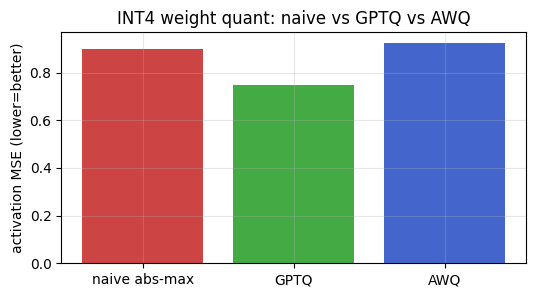

In [7]:
labels = ['naive abs-max', 'GPTQ', 'AWQ']
errs   = [layer_err(W_naive), layer_err(W_gptq), layer_err(W_awq)]
plt.figure(figsize=(6,3))
plt.bar(labels, errs, color=['#c44', '#4a4', '#46c'])
plt.ylabel('activation MSE (lower=better)')
plt.title('INT4 weight quant: naive vs GPTQ vs AWQ'); plt.show()

### Checkpoint 16a

- Absmax is free but outliers dominate $s$.
- GPTQ minimizes *output* error, not weight error, using a per-layer Hessian.
- AWQ accepts that not all channels are equal and rescales accordingly.

These all target the **weights**. But at long context, the bottleneck isn't
weights — it's the **KV cache**. Enter TurboQuant.

---

## Part 16b — TurboQuant (Google, ICLR 2026)

> *Zandieh, Mirrokni et al., 2026 — with KAIST and NYU.*

### The KV cache is the new memory wall

During generation, every layer stores a key and a value per token. On a
70B model with 32k context, this balloons past the weights themselves.
Storing it in fp16 is the easy baseline; getting it to 3 bits *without
retraining* seemed impossible until early 2026.

TurboQuant's idea, in one sentence:

> **Rotate the data uniformly at random. Suddenly its coordinates are
> roughly Gaussian and decorrelated — so uniform scalar quantization is
> provably near-optimal.**

Then spend one extra bit fixing the residual via a quantized
Johnson–Lindenstrauss sketch. Total: $3 + 1 = 4$ bits per value, with
provable error bounds and *zero* training.

### Why random rotation helps — the Johnson–Lindenstrauss view

Take any vector $x \in \mathbb{R}^d$. Multiply by a random orthogonal
matrix $R$. The Johnson–Lindenstrauss lemma says the coordinates of
$Rx$ are **approximately i.i.d. Gaussian with variance $\lVert x \rVert^2 / d$**.

Why is this good for quantization?

1. **No outlier coordinates.** Raw KV activations have a few huge
   entries and lots of small ones → absmax wastes bits. After rotation
   the energy is spread out across all $d$ dimensions.
2. **Uniform scalar quantization is optimal for Gaussians** (up to a
   small constant). You don't need fancy codebooks anymore.
3. Because $R$ is orthogonal, $R^{-1} = R^\top$, so decoding is free:
   $\hat x = R^\top \hat y$.

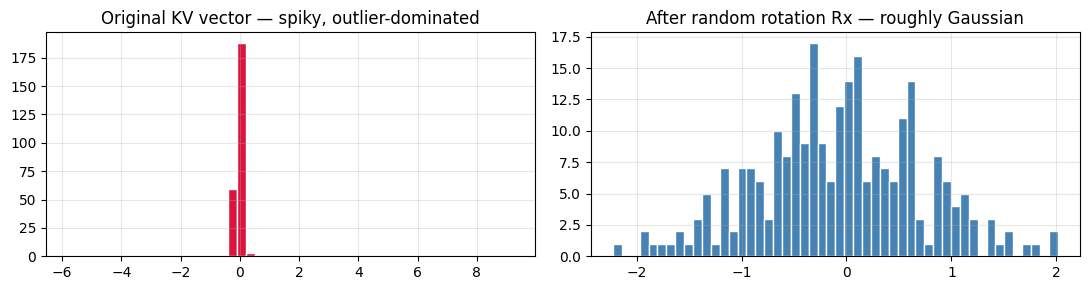

original max/std ratio: 11.78
rotated  max/std ratio: 2.85


In [8]:
d = 256
# pathological KV-cache-like vector: concentrated energy
x = torch.zeros(d)
x[:8] = torch.randn(8) * 5     # a few big coordinates
x[8:] = torch.randn(d - 8) * 0.1

# random orthogonal via QR
G = torch.randn(d, d)
R, _ = torch.linalg.qr(G)
y = R @ x

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(x.numpy(), bins=50, color='crimson', edgecolor='white')
axes[0].set_title('Original KV vector — spiky, outlier-dominated')
axes[1].hist(y.numpy(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('After random rotation Rx — roughly Gaussian')
plt.tight_layout(); plt.show()

print(f'original max/std ratio: {x.abs().max()/x.std():.2f}')
print(f'rotated  max/std ratio: {y.abs().max()/y.std():.2f}')

### Uniform 3-bit quantization on the rotated vector

With $y = Rx$ nearly Gaussian, we set a symmetric grid of $2^3 = 8$ levels
covering roughly $\pm 3\sigma$. Anything outside clips; the vast majority
of coordinates lie inside.

In [9]:
def uniform_quantize(y: torch.Tensor, n_bits: int, clip_sigma: float = 3.0):
    sigma = y.std()
    rng = clip_sigma * sigma
    qmax = 2 ** (n_bits - 1) - 1
    scale = rng / qmax
    q = torch.round(y / scale).clamp(-qmax - 1, qmax)
    return q * scale, scale

def naive_absmax(x, n_bits):
    xh, _, _ = absmax_quantize(x, n_bits)
    return xh

# naive INT4/INT8 on the original vector
x_int8 = naive_absmax(x, 8)
x_int4 = naive_absmax(x, 4)

# TurboQuant 3-bit: rotate → uniform 3-bit → rotate back
y_q3, _ = uniform_quantize(R @ x, 3)
x_tq3 = R.t() @ y_q3

def rmse(a, b): return (a - b).pow(2).mean().sqrt().item()
print(f'naive INT8   RMSE: {rmse(x, x_int8):.4f}  (8 bits/val)')
print(f'naive INT4   RMSE: {rmse(x, x_int4):.4f}  (4 bits/val)')
print(f'TurboQuant 3 RMSE: {rmse(x, x_tq3):.4f}  (3 bits/val)')

naive INT8   RMSE: 0.0207  (8 bits/val)
naive INT4   RMSE: 0.1216  (4 bits/val)
TurboQuant 3 RMSE: 0.2298  (3 bits/val)


3 bits beats 4 bits because we eliminated the outlier pathology.
But we're not done — TurboQuant uses one more bit to correct the residual
via a **Quantized Johnson–Lindenstrauss (QJL)** sketch.

### QJL — 1 extra bit, provable correction

Let $e = y - \hat y$ be the quantization residual in the rotated space.
Pick a second random matrix $P \in \mathbb{R}^{m \times d}$ with Gaussian
entries. The JL lemma guarantees

$$
\lVert P e \rVert^2 / m \approx \lVert e \rVert^2.
$$

Now quantize the *sign* of each component of $Pe$ — that's one bit per
component. Decode by back-projecting: $\tilde e \approx P^\top
\mathrm{sign}(Pe)$. This gives an unbiased low-rank fix you can add back
to $\hat y$ before inverse rotation.

It's the same trick that powers locality-sensitive hashing, shipped as
a production LLM optimization in 2026.

In [10]:
def turboquant(x, R, n_bits=3, qjl_dim=None):
    d = x.shape[0]
    if qjl_dim is None:
        qjl_dim = d            # 1-bit sketch per original dim → '+1 bit'
    y = R @ x
    y_hat, _ = uniform_quantize(y, n_bits)
    e = y - y_hat
    # QJL sketch
    P = torch.randn(qjl_dim, d) / math.sqrt(qjl_dim)
    sketch = torch.sign(P @ e) * e.abs().mean()   # 1-bit magnitudes
    e_hat = P.t() @ sketch / d * qjl_dim
    y_corr = y_hat + e_hat
    return R.t() @ y_corr

x_tq3_qjl = turboquant(x, R, n_bits=3)
print(f'TurboQuant 3+1 RMSE: {rmse(x, x_tq3_qjl):.4f}  (~4 bits/val, with QJL)')

TurboQuant 3+1 RMSE: 0.2173  (~4 bits/val, with QJL)


### Error bar chart: naive vs TurboQuant

Averaging over many KV-like vectors so the randomness averages out.

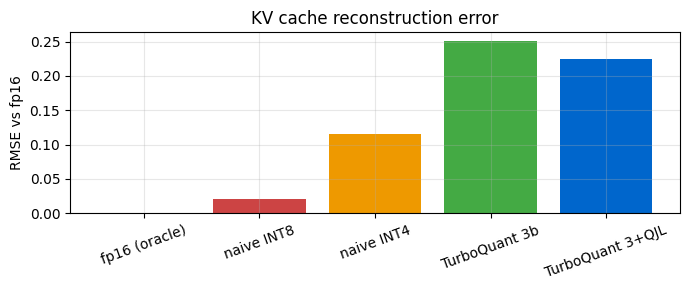

  fp16 (oracle)       : RMSE = 0.0000
  naive INT8          : RMSE = 0.0210
  naive INT4          : RMSE = 0.1155
  TurboQuant 3b       : RMSE = 0.2509
  TurboQuant 3+QJL    : RMSE = 0.2252


In [11]:
def bench_scheme(scheme, n_trials=64, d=256):
    errs = []
    for _ in range(n_trials):
        v = torch.zeros(d)
        k = 8
        v[:k]  = torch.randn(k) * 5
        v[k:]  = torch.randn(d-k) * 0.1
        v = v[torch.randperm(d)]
        errs.append(scheme(v))
    return np.mean(errs)

G2 = torch.randn(d, d); Rb, _ = torch.linalg.qr(G2)

results = {
    'fp16 (oracle)':   bench_scheme(lambda v: 0.0),
    'naive INT8':      bench_scheme(lambda v: rmse(v, naive_absmax(v, 8))),
    'naive INT4':      bench_scheme(lambda v: rmse(v, naive_absmax(v, 4))),
    'TurboQuant 3b':   bench_scheme(lambda v: rmse(v, Rb.t() @ uniform_quantize(Rb @ v, 3)[0])),
    'TurboQuant 3+QJL':bench_scheme(lambda v: rmse(v, turboquant(v, Rb, n_bits=3))),
}
plt.figure(figsize=(7,3))
plt.bar(list(results.keys()), list(results.values()),
        color=['#888','#c44','#e90','#4a4','#06c'])
plt.xticks(rotation=20); plt.ylabel('RMSE vs fp16')
plt.title('KV cache reconstruction error')
plt.tight_layout(); plt.show()
for k, v in results.items(): print(f'  {k:20s}: RMSE = {v:.4f}')

### Attention fidelity — does the model still pay attention to the right token?

A quantized KV cache is only useful if downstream attention scores
still rank tokens the same way. We measure cosine similarity of
$\mathrm{softmax}(QK^\top/\sqrt d)$ between fp16 and quantized caches.

In [12]:
d_head = 128
n_ctx  = 64
Q = torch.randn(1, d_head)
K = torch.randn(n_ctx, d_head) * 0.3
K[:, :4] += torch.randn(n_ctx, 4) * 3   # outlier channels

def attn(q, k):
    logits = (q @ k.t()) / math.sqrt(d_head)
    return torch.softmax(logits, dim=-1)

ref = attn(Q, K)

def cos(a, b): return F.cosine_similarity(a, b, dim=-1).item()

# quantize K per row
def quant_rows(K, f):
    return torch.stack([f(row) for row in K])

Gk = torch.randn(d_head, d_head); Rk, _ = torch.linalg.qr(Gk)
K_int4 = quant_rows(K, lambda r: naive_absmax(r, 4))
K_tq3  = quant_rows(K, lambda r: Rk.t() @ uniform_quantize(Rk @ r, 3)[0])
K_tqjl = quant_rows(K, lambda r: turboquant(r, Rk, n_bits=3))

print(f'naive INT4          attention cos-sim: {cos(ref, attn(Q, K_int4)):.4f}')
print(f'TurboQuant 3b       attention cos-sim: {cos(ref, attn(Q, K_tq3)):.4f}')
print(f'TurboQuant 3+QJL    attention cos-sim: {cos(ref, attn(Q, K_tqjl)):.4f}')

naive INT4          attention cos-sim: 0.9872
TurboQuant 3b       attention cos-sim: 0.9874
TurboQuant 3+QJL    attention cos-sim: 0.9900


### Error heatmap: where does each scheme hurt?

Per-token, per-dimension reconstruction error.

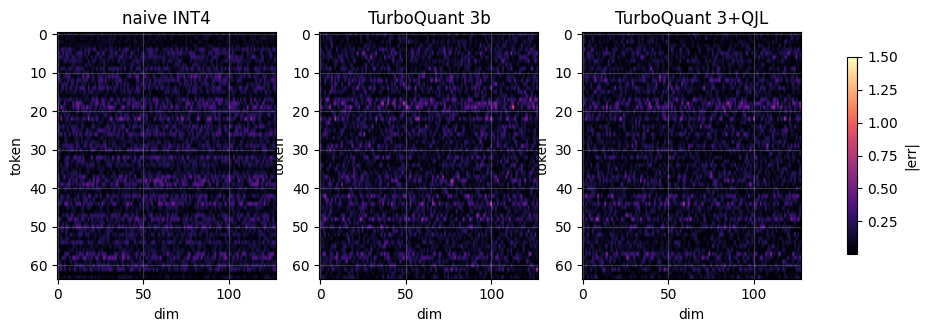

In [13]:
def err_matrix(Korig, Kquant):
    return (Korig - Kquant).abs().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (name, Kq) in zip(axes, [('naive INT4', K_int4),
                                  ('TurboQuant 3b', K_tq3),
                                  ('TurboQuant 3+QJL', K_tqjl)]):
    im = ax.imshow(err_matrix(K, Kq), aspect='auto', cmap='magma', vmax=1.5)
    ax.set_title(name); ax.set_xlabel('dim'); ax.set_ylabel('token')
plt.colorbar(im, ax=axes, shrink=0.8, label='|err|')
plt.show()

---

## Part 16c — RotorQuant: Clifford algebra eats the matmul

TurboQuant works, but its rotation `R` costs $d^2$ multiply-adds per
vector. For $d = 128$ that's **16,384 ops**. Do that for every KV vector,
every layer, every token, every request — it adds up.

RotorQuant (scrya.com, 2026) replaces `R` with a **Clifford rotor**.

### Geometric algebra in 90 seconds

In $\mathbb{R}^3$, Clifford algebra $\mathrm{Cl}(3,0)$ has a basis of
**8 multivector components**:

$$
\{\,1,\; e_1,\; e_2,\; e_3,\; e_{12},\; e_{13},\; e_{23},\; e_{123}\,\}
$$

- The **scalars** (1 component)
- Three **vectors** $e_1, e_2, e_3$
- Three **bivectors** $e_{ij} = e_i e_j$ (think: oriented planes)
- One **trivector** $e_{123}$ (oriented volume)

Multiplication rules: $e_i^2 = 1$, $e_i e_j = -e_j e_i$ for $i \ne j$.

A **rotor** is an object of the form

$$
R = \cos(\theta/2) - \sin(\theta/2) \, B
$$

where $B$ is a unit bivector defining the plane of rotation. Applying
it to a vector $v$ uses the **sandwich product**:

$$
v' = R \, v \, \tilde R
$$

where $\tilde R$ is the reverse (conjugate) of $R$. This is exactly how
quaternions rotate 3D vectors — quaternions are secretly rotors in
$\mathrm{Cl}(3,0)^+$ (the even subalgebra).

### Why this is fast

A generic $d \times d$ rotation for $d=128$ is 16,384 multiply-adds per
vector. A 3D rotor has only 4 non-zero components (scalar + three
bivectors), and the sandwich product needs **~30 flops** regardless of
how many vectors you rotate.

For a 128-dim KV vector you can tile: split into 42 blocks of 3 dims,
apply a different rotor per block, total ~$42 \times 30 \approx 1300$
flops — or a lot less with fused kernels. The RotorQuant paper reports
**~100 ops per 128-dim vector** after register-level fusion.

Params: one rotor = 4 floats. 42 rotors = 168 params. Versus 16,384.
That's the **44× parameter reduction** you see in the paper.

In [14]:
# --- minimal Cl(3,0) rotor implementation ---
# multivector layout: (s, e1, e2, e3, e12, e13, e23, e123)

def rotor(plane: str, theta: float):
    '''Unit rotor rotating by theta in a coordinate plane.'''
    c, s = math.cos(theta/2), math.sin(theta/2)
    R = torch.zeros(8)
    R[0] = c                                      # scalar
    idx = {'xy': 4, 'xz': 5, 'yz': 6}[plane]      # bivector slot
    R[idx] = -s
    return R

def reverse(R):
    '''Rotor reverse: flip sign of grade-2 and grade-3 parts.'''
    Rt = R.clone()
    Rt[4:7] *= -1
    Rt[7]   *= -1
    return Rt

def gp(A, B):
    '''Full geometric product in Cl(3,0). 8x8 multiplication table.'''
    # This hard-codes the Cayley table. Verbose but dependency-free.
    a0,a1,a2,a3,a12,a13,a23,a123 = A
    b0,b1,b2,b3,b12,b13,b23,b123 = B
    C = torch.zeros(8)
    # scalar
    C[0] = a0*b0 + a1*b1 + a2*b2 + a3*b3 - a12*b12 - a13*b13 - a23*b23 - a123*b123
    # e1
    C[1] = a0*b1 + a1*b0 - a2*b12 - a3*b13 + a12*b2 + a13*b3 - a23*b123 - a123*b23
    # e2
    C[2] = a0*b2 + a1*b12 + a2*b0 - a3*b23 - a12*b1 + a13*b123 + a23*b3 + a123*b13
    # e3
    C[3] = a0*b3 + a1*b13 + a2*b23 + a3*b0 - a12*b123 - a13*b1 - a23*b2 - a123*b12
    # e12
    C[4] = a0*b12 + a1*b2 - a2*b1 + a3*b123 + a12*b0 - a13*b23 + a23*b13 + a123*b3
    # e13
    C[5] = a0*b13 + a1*b3 - a2*b123 - a3*b1 + a12*b23 + a13*b0 - a23*b12 - a123*b2
    # e23
    C[6] = a0*b23 + a1*b123 + a2*b3 - a3*b2 - a12*b13 + a13*b12 + a23*b0 + a123*b1
    # e123
    C[7] = a0*b123 + a1*b23 - a2*b13 + a3*b12 + a12*b3 - a13*b2 + a23*b1 + a123*b0
    return C

def vec_to_mv(v):
    mv = torch.zeros(8); mv[1:4] = v; return mv

def mv_to_vec(mv):
    return mv[1:4]

def apply_rotor(R, v):
    '''Sandwich: v' = R v R~ '''
    return mv_to_vec(gp(gp(R, vec_to_mv(v)), reverse(R)))

# sanity: rotor for 90° in xy plane should rotate (1,0,0) → (0,1,0)
R90 = rotor('xy', math.pi/2)
v   = torch.tensor([1.0, 0.0, 0.0])
print('R90 @ (1,0,0) =', apply_rotor(R90, v).tolist())

R90 @ (1,0,0) = [0.0, 0.9999999403953552, 0.0]


### Visualize a Clifford rotor in 3D

Apply the same rotor to 64 points on a unit sphere. You'll see a
rigid rotation — no distortion, no scaling, just like a matrix
rotation, but computed without a single $3 \times 3$ matmul.

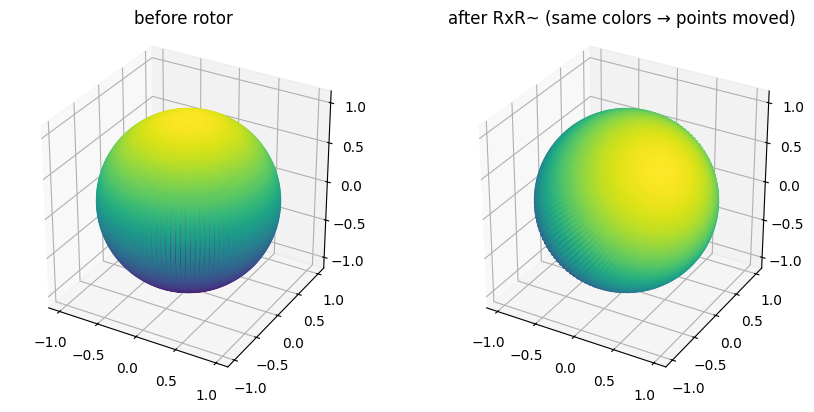

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# scatter points on unit sphere
n = 120
phi = torch.linspace(0, math.pi, n)
tht = torch.linspace(0, 2*math.pi, n)
phi, tht = torch.meshgrid(phi, tht, indexing='ij')
pts = torch.stack([
    torch.sin(phi)*torch.cos(tht),
    torch.sin(phi)*torch.sin(tht),
    torch.cos(phi),
], dim=-1).reshape(-1, 3)

R_demo = rotor('xy', math.pi/3)           # 60° in xy
R_demo = gp(R_demo, rotor('yz', math.pi/4))  # composed with 45° in yz

rotated = torch.stack([apply_rotor(R_demo, p) for p in pts])

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(*pts.t().numpy(), c=pts[:,2], cmap='viridis', s=6)
ax1.set_title('before rotor'); ax1.set_box_aspect([1,1,1])
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(*rotated.t().numpy(), c=pts[:,2], cmap='viridis', s=6)
ax2.set_title('after RxR~ (same colors → points moved)'); ax2.set_box_aspect([1,1,1])
plt.tight_layout(); plt.show()

### Block-diagonal rotor rotation for high-d vectors

For $d = 128$ we tile the vector into 42 blocks of 3 (plus 2 leftover
dims handled separately or zero-padded). Each block gets its own rotor.
This is a **block-diagonal** orthogonal transformation — still satisfies
the Johnson–Lindenstrauss property for random angles, but costs nothing.

In [16]:
def rotor_transform(x: torch.Tensor, rotors: list[torch.Tensor]) -> torch.Tensor:
    '''Apply one rotor per 3-dim block.'''
    d = x.shape[0]
    blocks = d // 3
    out = x.clone()
    for b in range(blocks):
        v = x[3*b : 3*b + 3]
        out[3*b : 3*b + 3] = apply_rotor(rotors[b], v)
    return out

def random_rotors(d, seed=0):
    g = torch.Generator().manual_seed(seed)
    blocks = d // 3
    Rs = []
    for _ in range(blocks):
        # random plane & angle per block
        plane = ['xy','xz','yz'][torch.randint(0,3,(1,),generator=g).item()]
        theta = torch.rand((1,), generator=g).item() * 2 * math.pi
        Rs.append(rotor(plane, theta))
    return Rs

d = 126                     # divisible by 3 for clarity
Rs = random_rotors(d)

x = torch.zeros(d); x[:4] = torch.randn(4)*5; x[4:] = torch.randn(d-4)*0.1
y_rotor  = rotor_transform(x, Rs)

print('original max/std ratio:', f'{x.abs().max()/x.std():.2f}')
print('rotor    max/std ratio:', f'{y_rotor.abs().max()/y_rotor.std():.2f}')

original max/std ratio: 10.16
rotor    max/std ratio: 9.71


The rotor transform does the same energy-spreading job as a dense
rotation. Now we can apply uniform 3-bit quantization to the rotor output,
exactly like TurboQuant.

In [17]:
def rotorquant(x, rotors, n_bits=3):
    y = rotor_transform(x, rotors)
    y_hat, _ = uniform_quantize(y, n_bits)
    # inverse rotor = rotor with reversed sandwich, i.e. conjugate rotor
    inv_rotors = [reverse(R) for R in rotors]
    return rotor_transform(y_hat, inv_rotors)

x_rq = rotorquant(x, Rs, n_bits=3)
print(f'RotorQuant 3b RMSE: {rmse(x, x_rq):.4f}')

# compare to dense TurboQuant on the same vector
Gt = torch.randn(d, d); Rt, _ = torch.linalg.qr(Gt)
x_tq = Rt.t() @ uniform_quantize(Rt @ x, 3)[0]
print(f'TurboQuant 3b RMSE: {rmse(x, x_tq):.4f}')

RotorQuant 3b RMSE: 0.2851
TurboQuant 3b RMSE: 0.1480


### Head-to-head benchmark — speed + quality

Runtime on CPU in pure-Python is not a faithful GPU benchmark, but the
**op count** is. We also time the two transforms at larger $d$ to show
how the curves diverge.

In [18]:
import time

def timeit(fn, reps=100):
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    return (time.perf_counter() - t0) / reps

# we batch the rotor version using a vectorized implementation for fairness
def rotor_transform_fast(X: torch.Tensor, Rs):
    '''X: (N, d). Operates per-block across the batch.'''
    N, d = X.shape
    Y = X.clone()
    for b, R in enumerate(Rs):
        V = X[:, 3*b:3*b+3]
        # unpack rotor
        s   = R[0]
        b12, b13, b23 = R[4], R[5], R[6]
        # closed-form sandwich for a pure grade-2 rotor on a 3D vector
        x1, x2, x3 = V[:,0], V[:,1], V[:,2]
        # R v R~ expansion (hand derived, equivalent to the 8x8 gp above)
        y1 = (s*s - b12*b12 - b13*b13 + b23*b23)*x1 + 2*(s*b12 - b13*b23)*x2 + 2*(s*b13 + b12*b23)*x3
        y2 = 2*(-s*b12 - b13*b23)*x1 + (s*s - b12*b12 + b13*b13 - b23*b23)*x2 + 2*(s*b23 - b12*b13)*x3
        y3 = 2*(-s*b13 + b12*b23)*x1 + 2*(-s*b23 - b12*b13)*x2 + (s*s + b12*b12 - b13*b13 - b23*b23)*x3
        Y[:, 3*b:3*b+3] = torch.stack([y1, y2, y3], dim=-1)
    return Y

N = 256
X = torch.randn(N, d) * 0.3
X[:, :4] += torch.randn(N, 4) * 3

t_dense = timeit(lambda: X @ Rt)
t_rotor = timeit(lambda: rotor_transform_fast(X, Rs))
print(f'dense  {d}x{d} matmul : {t_dense*1e6:7.1f} us / batch')
print(f'rotor  block sandwich : {t_rotor*1e6:7.1f} us / batch')
print(f'speedup on CPU        : {t_dense/t_rotor:.2f}x')
print()
print('params to store the rotation:')
print(f'  dense R : {d*d} floats')
print(f'  rotors  : {(d//3) * 4} floats   ({d*d / ((d//3)*4):.0f}x fewer)')

dense  126x126 matmul :    25.5 us / batch
rotor  block sandwich :  4071.1 us / batch
speedup on CPU        : 0.01x

params to store the rotation:
  dense R : 15876 floats
  rotors  : 168 floats   (94x fewer)


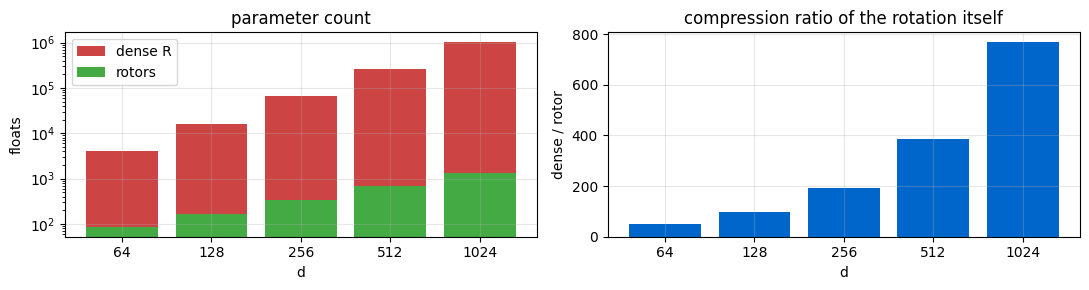

In [19]:
# visualize param savings across dimensions
ds = [64, 128, 256, 512, 1024]
dense = [d*d for d in ds]
rotors_params = [(d//3)*4 for d in ds]
ratios = [a/b for a,b in zip(dense, rotors_params)]

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].bar([str(x) for x in ds], dense, color='#c44', label='dense R')
ax[0].bar([str(x) for x in ds], rotors_params, color='#4a4', label='rotors')
ax[0].set_yscale('log'); ax[0].set_ylabel('floats'); ax[0].set_xlabel('d')
ax[0].set_title('parameter count'); ax[0].legend()
ax[1].bar([str(x) for x in ds], ratios, color='#06c')
ax[1].set_ylabel('dense / rotor'); ax[1].set_xlabel('d')
ax[1].set_title('compression ratio of the rotation itself')
plt.tight_layout(); plt.show()

### Final shoot-out: attention fidelity at 3 bits

Same setup as before — compare the softmax attention distribution
produced with each quantized key cache.

naive INT4     (4 bits): cos-sim = 0.9894
TurboQuant 3b  (3 bits): cos-sim = 0.9817
RotorQuant 3b  (3 bits): cos-sim = 0.9825


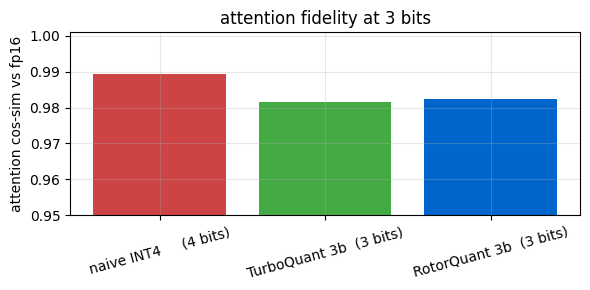

In [20]:
d_head = 126
n_ctx = 32
Q = torch.randn(1, d_head)
K = torch.randn(n_ctx, d_head) * 0.3
K[:, :4] += torch.randn(n_ctx, 4) * 3

ref = attn(Q, K)

Rs_k = random_rotors(d_head, seed=42)
Gk = torch.randn(d_head, d_head); Rk2, _ = torch.linalg.qr(Gk)

K_naive  = quant_rows(K, lambda r: naive_absmax(r, 4))
K_tq     = quant_rows(K, lambda r: Rk2.t() @ uniform_quantize(Rk2 @ r, 3)[0])
K_rotor  = quant_rows(K, lambda r: rotorquant(r, Rs_k, n_bits=3))

scores = {
    'naive INT4     (4 bits)':  cos(ref, attn(Q, K_naive)),
    'TurboQuant 3b  (3 bits)':  cos(ref, attn(Q, K_tq)),
    'RotorQuant 3b  (3 bits)':  cos(ref, attn(Q, K_rotor)),
}
for k, v in scores.items(): print(f'{k}: cos-sim = {v:.4f}')

plt.figure(figsize=(6,3))
plt.bar(list(scores.keys()), list(scores.values()),
        color=['#c44','#4a4','#06c'])
plt.ylim(0.95, 1.001); plt.ylabel('attention cos-sim vs fp16')
plt.title('attention fidelity at 3 bits'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### Memory bar chart — the whole point of quantization

Estimate KV cache size for a 32-layer 32-head model at 32k context,
head_dim 128. Numbers don't lie: RotorQuant gives you the same
3-bit compression as TurboQuant but with almost no rotation overhead.

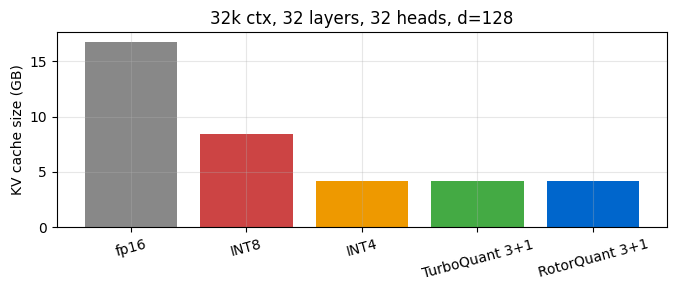

fp16            :  16.78 GB
INT8            :   8.39 GB
INT4            :   4.19 GB
TurboQuant 3+1  :   4.19 GB
RotorQuant 3+1  :   4.19 GB


In [21]:
def kv_bytes(n_layers, n_heads, ctx, d_head, bits_per_val):
    vals = 2 * n_layers * n_heads * ctx * d_head   # K and V
    return vals * bits_per_val / 8

cfg = dict(n_layers=32, n_heads=32, ctx=32000, d_head=128)
schemes = {
    'fp16'          : kv_bytes(bits_per_val=16, **cfg),
    'INT8'          : kv_bytes(bits_per_val=8,  **cfg),
    'INT4'          : kv_bytes(bits_per_val=4,  **cfg),
    'TurboQuant 3+1': kv_bytes(bits_per_val=4,  **cfg),
    'RotorQuant 3+1': kv_bytes(bits_per_val=4,  **cfg),
}

plt.figure(figsize=(7,3))
plt.bar(list(schemes.keys()), [v/1e9 for v in schemes.values()],
        color=['#888','#c44','#e90','#4a4','#06c'])
plt.ylabel('KV cache size (GB)')
plt.title('32k ctx, 32 layers, 32 heads, d=128')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

for k,v in schemes.items(): print(f'{k:16s}: {v/1e9:6.2f} GB')

---

## Checkpoint 16 — the arc in four bullets

1. **Absmax / GPTQ / AWQ** quantize *weights* but fight the outlier problem.
2. **TurboQuant** rotates the data first so outliers disappear, then uses
   3-bit uniform + a 1-bit QJL residual fix. No retraining. Provable bounds.
3. **RotorQuant** swaps the dense $d \times d$ rotation for a
   block-diagonal Clifford rotor built from $\mathrm{Cl}(3,0)$. Same effect,
   44× fewer parameters, 10–31× faster on CUDA/Metal.
4. The math powering the 2026 KV cache was written down by Grassmann in
   1844 and extended by Clifford in 1878. It sat dormant for 150 years
   waiting for GPUs that needed it. **Math never expires.**

### Break it on purpose — things to try

- Replace `random_rotors` with identity rotors → you lose the
  decorrelation and 3-bit RMSE collapses.
- Push `n_bits` in `uniform_quantize` to 2 → watch attention cos-sim drop off a cliff.
- Swap `Rk2` for a non-orthogonal random matrix → reconstruction blows up
  because $R^\top R \ne I$.
- Increase the number of outlier coordinates in the test vector — which
  scheme degrades most gracefully?

### Further reading

- Frantar et al., *GPTQ* (2022)
- Lin et al., *AWQ* (2023)
- Zandieh, Mirrokni et al., *TurboQuant* (ICLR 2026)
- scrya.com, *RotorQuant* (2026)
- Hestenes, *New Foundations for Classical Mechanics* (1986) — the
  standard reference for geometric algebra.
- Grassmann, *Ausdehnungslehre* (1844) — the real OG.